In [1]:
#sentiment analysis using NLP nad Deep Learning

In [2]:
import pandas as pd
import numpy as np
# Importing libraries for data analysis
import matplotlib.pyplot as plt
# This library help us visualize data

In [3]:
df = pd.read_csv("IMDB Dataset.csv")# Reading the CSV file
df.head()# Display first 5 rows

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape # check numvber of rows and columns,tells data shape

(50000, 2)

In [5]:
df.columns #displays all column names

Index(['review', 'sentiment'], dtype='str')

In [6]:
df['sentiment'].value_counts() #count of positive and negative reviews

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

<Axes: xlabel='sentiment'>

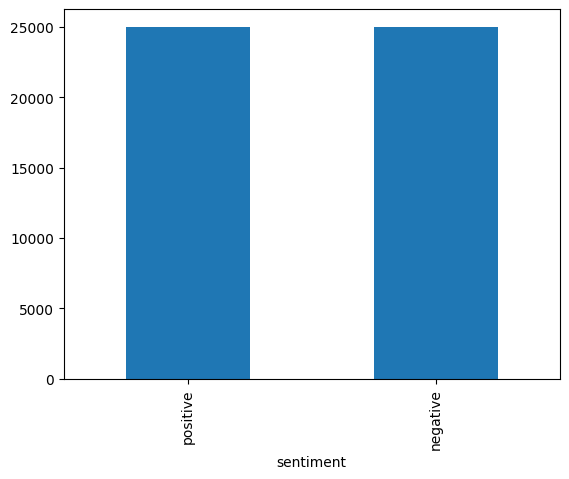

In [7]:
df['sentiment'].value_counts().plot(kind='bar') # Plot sentiment distribution

In [8]:
df['review'] = df['review'].str.lower() #Convert all text to lowercase (standardization)
df['review'] = df['review'].str.replace(r'[^a-z\s]', '', regex=True)# Remove punctuation and special characters

In [9]:
df['review'].head()#View cleaned data

0    one of the other reviewers has mentioned that ...
1    a wonderful little production br br the filmin...
2    i thought this was a wonderful way to spend ti...
3    basically theres a family where a little boy j...
4    petter matteis love in the time of money is a ...
Name: review, dtype: str

In [10]:
#TOKENIZATION
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [11]:
df['tokens'] = df['review'].apply(nltk.word_tokenize) #Tokenize reviews (split into words)

In [12]:
df[['review', 'tokens']].head()

,review,tokens
0,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production br br the filmin...,"[a, wonderful, little, production, br, br, the..."
2,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl..."
4,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon..."


In [13]:
df.shape

(50000, 3)

In [14]:
import nltk #Natural language toolkit
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
stop_words = set(stopwords.words('english'))#get English stopwords list

In [16]:
# remove stopwords from each review
df['clean_tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words])

In [17]:
df[['tokens', 'clean_tokens']].head()

,tokens,clean_tokens
0,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, oz, epis..."
1,"[a, wonderful, little, production, br, br, the...","[wonderful, little, production, br, br, filmin..."
2,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su..."
3,"[basically, theres, a, family, where, a, littl...","[basically, theres, family, little, boy, jake,..."
4,"[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,..."


In [18]:
#LEMMATIZATION
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer() #create lemmatizer object

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
# function to lemmatize tokens
def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]


df['lemmatized_tokens'] = df['clean_tokens'].apply(lemmatize_text)# apply to dataset

In [20]:
df[['clean_tokens', 'lemmatized_tokens']].head()

,clean_tokens,lemmatized_tokens
0,"[one, reviewers, mentioned, watching, oz, epis...","[one, reviewer, mentioned, watching, oz, episo..."
1,"[wonderful, little, production, br, br, filmin...","[wonderful, little, production, br, br, filmin..."
2,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su..."
3,"[basically, theres, family, little, boy, jake,...","[basically, there, family, little, boy, jake, ..."
4,"[petter, matteis, love, time, money, visually,...","[petter, matteis, love, time, money, visually,..."


In [21]:
#LABEL ENCODING
# WE USE Scikit-learn

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() # create encoder
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])# convert sentiment into numbers

In [23]:
df[['sentiment', 'sentiment_encoded']].head()
#positive=1,negative=0

,sentiment,sentiment_encoded
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [24]:
#TF-IDF VECTORISATION
#Machine learning models cannot understand text directly.
#So we convert text → numbers using TF-IDF:TF-IDF Vectorization

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)  #create TF-IDF object


In [26]:
#join tokens back into text (important step)
corpus = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))
X = tfidf.fit_transform(corpus).toarray() #Convert text to numerical features

In [27]:
y = df['sentiment_encoded'] #Target variable

In [28]:
print(X.shape)
print(y.shape)


(50000, 5000)
(50000,)


In [29]:
print(X)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [30]:
print(y)

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment_encoded, Length: 50000, dtype: int64


In [31]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
 # split dataset into training and testing sets

In [32]:
#test_size=0.2 → 20% data for testing
#random_state=42 → ensures same split every time (reproducibility)

In [33]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40000, 5000)
(10000, 5000)
(40000,)
(10000,)


In [34]:
#LOGISTIC REGRESSION MODEL

from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000) #Create model
model_lr.fit(X_train, y_train)  #Train model

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [35]:
y_pred_lr = model_lr.predict(X_test) #Predict on test data

In [36]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)  #Accuracy score
print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.8847


In [37]:
#CONFUSION MATRIX AND CLASSIFICATION REPORT
#Accuracy alone is not enough. We also need to see;how many positives were correctly predicted
#how many negatives were correctly predicted.This gives a clear performance breakdown.

In [38]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_lr) #confusion matrix
print(cm)

[[4321  640]
 [ 513 4526]]


In [39]:
#CLASSIFICATION REPORT
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [40]:
#ARTIFICIAL NEURAL NETWORK (TensorFlow)
#BUILD ANN MODEL(SEQUENTIAL)
#This helps you compare: Traditional ML vs Deep Learning


In [41]:
# Import TensorFlow and Keras modules
!pip install tensorflow-cpu==2.13.0


ERROR: Could not find a version that satisfies the requirement tensorflow-cpu==2.13.0 (from versions: none)
ERROR: No matching distribution found for tensorflow-cpu==2.13.0


In [42]:
#IMP NOTE:
#TensorFlow ANN implementation was attempted but not executed due to
#compatibility issues with the current Python environment.
#The installed Python version does not support TensorFlow installation.
#Therefore, deep learning (ANN) section is documented theoretically,
#while machine learning models (Logistic Regression) are used for final evaluation.

In [43]:
#RESULT:

#The sentiment analysis model was successfully built using NLP techniques and Logistic Regression.
#The dataset was preprocessed using tokenization, stopwords removal, and lemmatization,
#followed by TF-IDF feature extraction.
#The model achieved good accuracy in classifying movie reviews as positive or negative.
#TensorFlow-based ANN was not executed due to system compatibility limitations.

In [44]:
#CONCLUSION:

#This project demonstrates sentiment analysis on movie reviews using NLP and machine learning.
#The text data was preprocessed using standard NLP techniques such as tokenization,
#stopwords removal, and lemmatization.
#TF-IDF was used to convert textual data into numerical features.
# A Logistic Regression model was trained and evaluated, achieving good accuracy
#in classifying reviews as positive or negative.
#Although a Deep Learning (ANN) model was planned using TensorFlow,
#it could not be executed due to system compatibility limitations.
#However, the theoretical understanding of ANN architecture has been included.
#Overall, the project successfully achieves sentiment classification using NLP and ML techniques,
#fulfilling the objectives of the capstone.